# Tech Challenge - Fase 4: Modelo Preditivo para Diagnóstico de Obesidade

**Contexto de Negócio:** Desenvolvimento de um pipeline de Machine Learning de ponta a ponta para classificar e prever o risco de obesidade de pacientes. O objetivo é fornecer uma ferramenta de suporte à decisão clínica e analítica para a equipe médica.
<div align="center">
  <img src="https://raw.githubusercontent.com/maikej910-del/notebooks-Grupo_45/main/logo.jpeg" alt="Logo Grupo 45" width="350">
</div>
<br>

## 1. Configuração do Ambiente e Ingestão de Dados
Estabelecimento das dependências estruturais e ingestão da base de dados bruta diretamente do repositório remoto. A abordagem *code-first* elimina a necessidade de uploads manuais, garantindo a reprodutibilidade do experimento.

In [1]:
# Instalação da biblioteca de exportação de Excel no ambiente atual
!pip install xlsxwriter -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import io
import sklearn
import xlsxwriter
from IPython.display import display, Markdown
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Paleta de cores do projeto
cor_principal_texto = "#0F382B"
cor_barras_principais = "#1D5E4D"
cor_elementos_secundarios = "#3B7E67"
cor_destaque_media = "#B98F53"
cor_alerta_destaque = "#DDB87E"

# Configuração de estilo
sns.set_theme(style="whitegrid", palette=[cor_barras_principais, cor_elementos_secundarios, cor_destaque_media, cor_alerta_destaque])
plt.rcParams['text.color'] = cor_principal_texto
plt.rcParams['axes.labelcolor'] = cor_principal_texto
plt.rcParams['xtick.color'] = cor_principal_texto
plt.rcParams['ytick.color'] = cor_principal_texto

# URL Raw do arquivo no GitHub do Grupo 45
url_github = 'https://raw.githubusercontent.com/maikej910-del/notebooks-Grupo_45/main/Obesity.csv'

# Padronização das features para o contexto de negócio local
traducao_colunas = {
    'Gender': ('Genero', {'Female': 'Feminino' , 'Male': 'Masculino'}),
    'Age': ('Idade', 0),
    'Height': ('Altura', 0),
    'Weight': ('Peso', 0),
    'family_history': ('Historico_Familiar', {'yes': 'Sim', 'no': 'Nao'}),
    'FAVC': ('Consumo_Alta_Caloria', {'yes': 'Sim', 'no': 'Nao'}),
    'FCVC': ('Consumo_Vegetais', 0),
    'NCP': ('Refeicoes_Dia', 0),
    'CAEC': ('Consumo_Entre_Refeicoes', {'no': 'Nao', 'Sometimes': 'As vezes', 'Frequently': 'Frequentemente', 'Always': 'Sempre'}),
    'SMOKE': ('Fumante', {'yes': 'Sim', 'no': 'Nao'}),
    'CH2O': ('Consumo_Agua', 0),
    'SCC': ('Monitora_Calorias', {'yes': 'Sim', 'no': 'Nao'}),
    'FAF': ('Frequencia_Ativ_Fisica', 0),
    'TUE': ('Tempo_Telas', 0),
    'CALC': ('Consumo_Alcool', {'no': 'Nao', 'Sometimes': 'As vezes', 'Frequently': 'Frequentemente', 'Always': 'Sempre'}),
    'MTRANS': ('Meio_Transporte', {'Automobile': 'Carro', 'Motorbike': 'Moto', 'Public_Transportation': 'Transporte Publico', 'Bike': 'Bicicleta', 'Walking': 'A pe'}),
    'Obesity': ('Classe_Peso', {'Insufficient_Weight': 'Abaixo do peso', 'Normal_Weight': 'Peso normal', 'Overweight_Level_I': 'Sobrepeso I', 'Overweight_Level_II': 'Sobrepeso II', 'Obesity_Type_I': 'Obesidade I', 'Obesity_Type_II': 'Obesidade II', 'Obesity_Type_III': 'Obesidade III'})
}

## 2. Tratamento e Feature Engineering
Criação de funções para mapear os dados textuais e gerar métricas clínicas calculadas (IMC e Score de Atividade). A base foi separada em `df_modelo` (para treinamento) e `df_analise` (para visualização e dashboards).

In [2]:
def traducao_dataframe(dataframe, tipo):
    df = dataframe
    for coluna_original, traducao in traducao_colunas.items():
        novo_nome    = traducao[0]
        mapa_valores = traducao[1]
        if coluna_original in df.columns:
            if isinstance(mapa_valores, dict):
                df[coluna_original] = df[coluna_original].map(lambda x: mapa_valores[x] if x in mapa_valores else x)
            df.rename(columns={coluna_original: novo_nome}, inplace=True)
    return df

def carregar_obesidade(arquivo, tipo):
    df = pd.read_csv(arquivo, sep=",")
    traducao_dataframe(df, tipo)

    # Ajuste de tipagem e separador decimal
    if df["Altura"].dtype == 'O':
        df["Altura"] = df["Altura"].astype(str).str.replace(",", ".").astype(float)
    if df["Peso"].dtype == 'O':
        df["Peso"] = df["Peso"].astype(str).str.replace(",", ".").astype(float)

    # Engenharia de Features (Cálculo do IMC e Score de Atividade)
    df["IMC"] = round(df["Peso"] / (df["Altura"] ** 2), 2)
    df['Score_Atividade'] = df['Frequencia_Ativ_Fisica'] * df['Tempo_Telas']

    # Tratamentos de texto para base de análise
    if tipo == 'analise':
        colunas_escala = ['Consumo_Vegetais', 'Refeicoes_Dia', 'Consumo_Agua', 'Frequencia_Ativ_Fisica', 'Tempo_Telas']
        for col in colunas_escala:
            df[col] = df[col].round().astype(int)

        df['Consumo_Vegetais'] = df['Consumo_Vegetais'].map({1: 'Raramente', 2: 'As vezes', 3: 'Sempre'})
        df['Refeicoes_Dia'] = df['Refeicoes_Dia'].map({1: '1 refeicao', 2: '2 refeicoes', 3: '3 refeicoes', 4: '4 ou mais'})
        df['Consumo_Agua'] = df['Consumo_Agua'].map({1: '< 1 L/dia', 2: '1-2 L/dia', 3: '> 2 L/dia'})
        df['Frequencia_Ativ_Fisica'] = df['Frequencia_Ativ_Fisica'].map({0: 'Nenhuma', 1: '1-2 dias/sem', 2: '3-4 dias/sem', 3: '5+ dias/sem'})
        df['Tempo_Telas'] = df['Tempo_Telas'].map({0: '0-2 h/dia', 1: '3-5 h/dia', 2: '> 5 h/dia'})

        df['Faixa_Etaria'] = pd.cut(df['Idade'], bins=[0, 12, 17, 39, 59, float('inf')], labels=['Infantil','Adolescente', 'Jovem Adulto', 'Adulto Meia Idade', 'Idoso'])

    print(f'Shape do Arquivo {tipo}: {df.shape}')
    return df

df_modelo = carregar_obesidade(url_github, 'modelo')
df_analise = carregar_obesidade(url_github, 'analise')

# Validação estrutural da base
display(df_modelo.head())

Shape do Arquivo modelo: (2111, 19)
Shape do Arquivo analise: (2111, 20)


,Genero,Idade,Altura,Peso,Historico_Familiar,Consumo_Alta_Caloria,Consumo_Vegetais,Refeicoes_Dia,Consumo_Entre_Refeicoes,Fumante,Consumo_Agua,Monitora_Calorias,Frequencia_Ativ_Fisica,Tempo_Telas,Consumo_Alcool,Meio_Transporte,Classe_Peso,IMC,Score_Atividade
0,Feminino,21.0,1.62,64.0,Sim,Nao,2.0,3.0,As vezes,Nao,2.0,Nao,0.0,1.0,Nao,Transporte Publico,Peso normal,24.39,0.0
1,Feminino,21.0,1.52,56.0,Sim,Nao,3.0,3.0,As vezes,Sim,3.0,Sim,3.0,0.0,As vezes,Transporte Publico,Peso normal,24.24,0.0
2,Masculino,23.0,1.80,77.0,Sim,Nao,2.0,3.0,As vezes,Nao,2.0,Nao,2.0,1.0,Frequentemente,Transporte Publico,Peso normal,23.77,2.0
3,Masculino,27.0,1.80,87.0,Nao,Nao,3.0,3.0,As vezes,Nao,2.0,Nao,2.0,0.0,Frequentemente,A pe,Sobrepeso I,26.85,0.0
4,Masculino,22.0,1.78,89.8,Nao,Nao,2.0,1.0,As vezes,Nao,2.0,Nao,0.0,0.0,As vezes,Transporte Publico,Sobrepeso II,28.34,0.0


## 3. Análise Exploratória de Dados (EDA)
Análise de distribuição da variável alvo e investigação de correlações lineares e multicolinearidade, garantindo a integridade dos dados antes da modelagem.

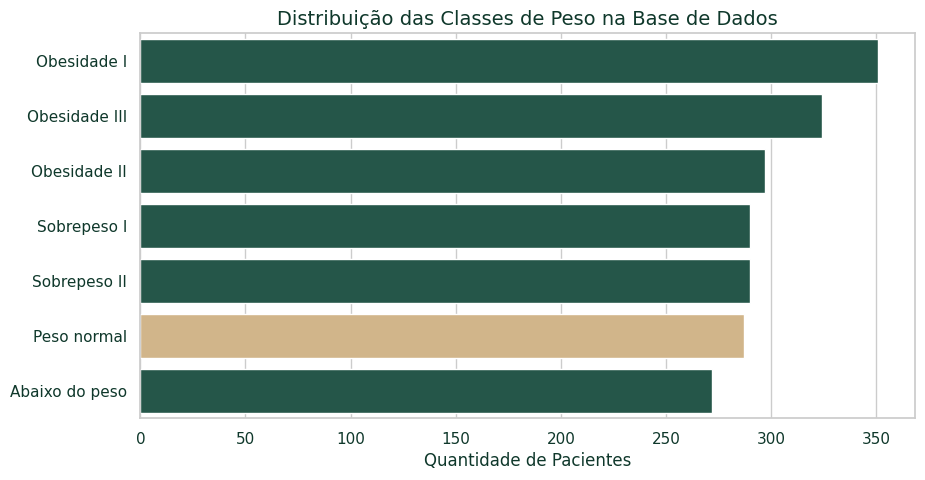

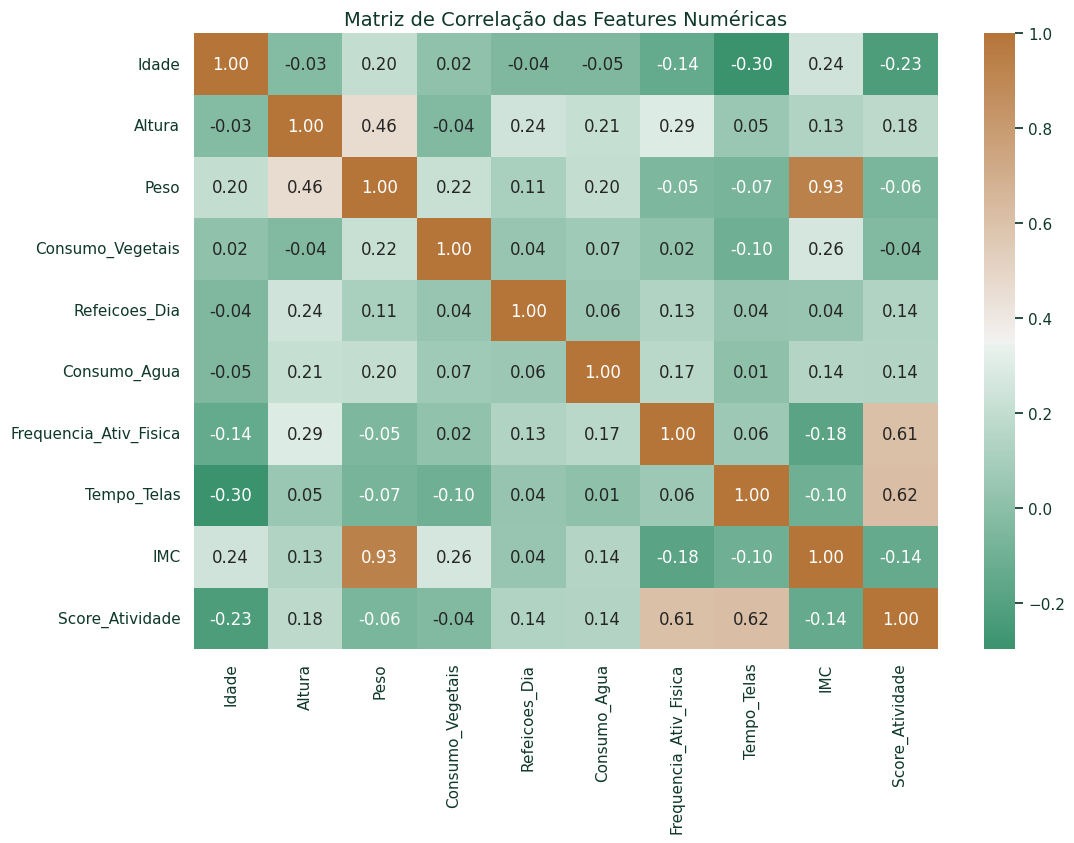

In [3]:
# Distribuição da variável alvo
plt.figure(figsize=(10, 5))
order = df_modelo['Classe_Peso'].value_counts().index
pal = {k: cor_alerta_destaque if k == 'Peso normal' else cor_barras_principais for k in order}
sns.countplot(y=df_modelo['Classe_Peso'], order=order, palette=pal, hue=df_modelo['Classe_Peso'], legend=False)
plt.title("Distribuição das Classes de Peso na Base de Dados", fontsize=14, color=cor_principal_texto)
plt.xlabel("Quantidade de Pacientes", color=cor_principal_texto)
plt.ylabel("", color=cor_principal_texto)
plt.show()

# Matriz de correlação
plt.figure(figsize=(12, 8))
colunas_num = df_modelo.select_dtypes(include=['float64', 'int64']).columns
cmap = sns.diverging_palette(150, 40, s=80, l=55, n=9, as_cmap=True)
sns.heatmap(df_modelo[colunas_num].corr(), annot=True, cmap=cmap, fmt=".2f")
plt.title("Matriz de Correlação das Features Numéricas", fontsize=14, color=cor_principal_texto)
plt.show()

## 4. Preparação dos Dados (Feature Selection)
Após a análise da matriz de correlação, observou-se que as variáveis `Peso` e `IMC` apresentam correlação superior a 90% com o `Target`, enquanto `Altura` não demonstra relevância significativa. Para evitar vazamento de dados (*data leakage*) e direcionar o modelo para aspectos clínicos e comportamentais, as variáveis relacionadas à massa corporal (`Peso` e `IMC`) foram removidas do conjunto de treinamento.

Mantivemos o `Score_Atividade` e os demais hábitos de vida. Dessa forma, a Árvore de Decisão passa a avaliar o risco preditivo com base nos comportamentos e no histórico do paciente, resultando em um modelo mais preventivo e menos dependente de indicadores antropométricos diretos.

In [4]:
# Remoção de Peso, Altura e IMC para focar 100% nas features comportamentais e genéticas
X = df_modelo.drop(columns=['Classe_Peso', 'Peso', 'IMC'])
y = df_modelo['Classe_Peso']

# Separação de treino e teste (com estratificação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

# Pipeline de transformação
colunas_numericas = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ]
)

## 5. Modelagem Preditiva, Avaliação e Deploy do App
O modelo selecionado foi o `RandomForestClassifier`. A sintonia fina (fine-tuning) do algoritmo teve como foco extrair o máximo de precisão do cruzamento dos hábitos de vida, provando que é possível prever obesidade sem usar o IMC.

Para garantir que as probabilidades preditivas fossem responsivas e graduais, o modelo foi calibrado com `class_weight='balanced'`, profundidade controlada (`max_depth=9`), suavização de folhas (`min_samples_leaf=6`) e uma visibilidade fracionada de features (`max_features=0.6`). A aplicação web (`app.py`) exportada mantém o cálculo do IMC apenas como um indicador visual para o médico, mas não o envia para a IA.

Acurácia do Modelo: 80.91%



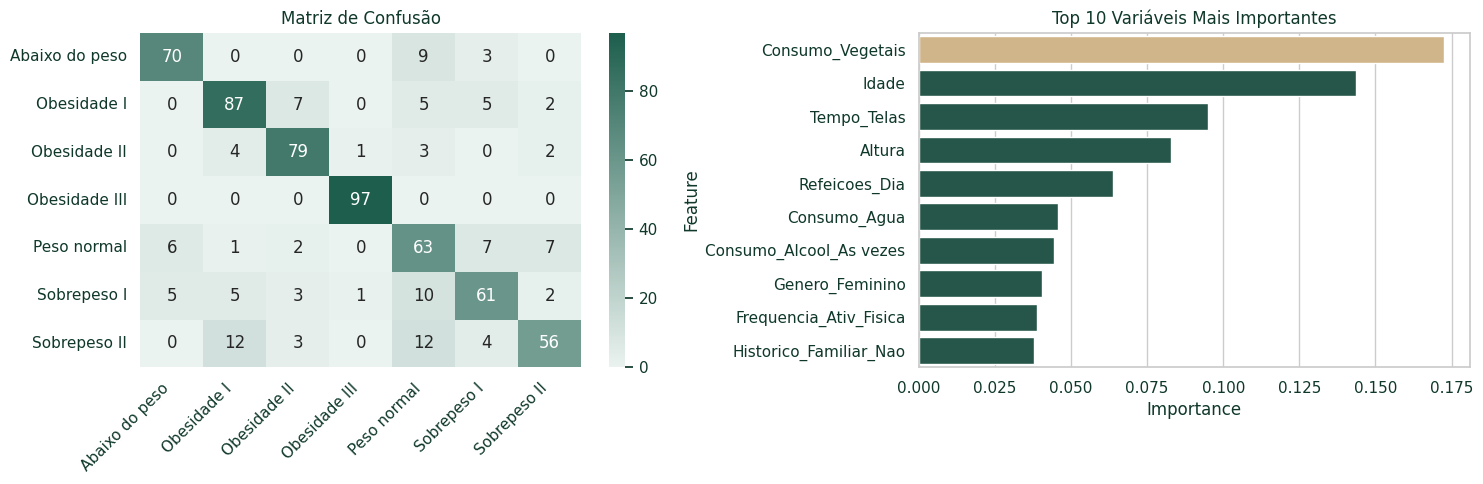

Artefatos gerados. Iniciando downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# 5.1. Construção e ajuste do modelo (Sintonia fina para responsividade de probabilidades)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessador),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=9,              # Profundidade ideal para não decorar os dados (overfitting)
        min_samples_leaf=6,       # Suaviza a decisão, deixando as % de probabilidade mais fluidas
        max_features=0.6,         # Visão de 60% das colunas
        random_state=42,
        class_weight='balanced',  # Retorna o peso para evitar tendência às classes majoritárias
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train_1d)

# 5.2. Avaliação no conjunto de teste
y_pred = pipeline_rf.predict(X_test)
acuracia = accuracy_score(y_test_1d, y_pred)
print(f"Acurácia do Modelo: {acuracia * 100:.2f}%\n")

# 5.3. Gráficos de validação do modelo
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_test_1d, y_pred, labels=pipeline_rf.classes_)
cmap_cm = sns.light_palette(cor_barras_principais, as_cmap=True)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap=cmap_cm, xticklabels=pipeline_rf.classes_, yticklabels=pipeline_rf.classes_)
ax[0].set_title("Matriz de Confusão", color=cor_principal_texto)
ax[0].set_xticklabels(pipeline_rf.classes_, rotation=45, ha='right', color=cor_principal_texto)

importances = pipeline_rf.named_steps['classifier'].feature_importances_
features = pipeline_rf.named_steps['preprocessor'].get_feature_names_out()
features_limpas = [f.replace("num__", "").replace("cat__", "") for f in features]
feat_df = pd.DataFrame({'Feature': features_limpas, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

feat_pal = {k: cor_alerta_destaque if k == feat_df.iloc[0]['Feature'] else cor_barras_principais for k in feat_df['Feature']}
sns.barplot(x='Importance', y='Feature', data=feat_df, ax=ax[1], palette=feat_pal, hue='Feature', legend=False)
ax[1].set_title("Top 10 Variáveis Mais Importantes", color=cor_principal_texto)

plt.tight_layout()
plt.show()

# 5.4. Escrita do código da aplicação Streamlit (app.py)
with open('app.py', 'w', encoding='utf-8') as f:
    f.write("""import streamlit as st
import joblib
import pandas as pd
import io
import altair as alt

st.set_page_config(page_title="Diagnóstico de Peso Corporal", layout="wide")

# Inserção do Logo ao lado do Título
col_logo, col_titulo = st.columns([1, 6])
with col_logo:
    st.image("https://raw.githubusercontent.com/maikej910-del/notebooks-Grupo_45/main/logo.jpeg", width=120)
with col_titulo:
    st.title("🔬 Sistema Clínico para Diagnóstico de Peso Corporal")

model = joblib.load('modelo_obesidade_rf.pkl')

nome_paciente = st.text_input("Nome Completo do Paciente", placeholder="Digite aqui...")

col1, col2, col3 = st.columns(3)

with col1:
    genero = st.selectbox("Gênero", ["", "Masculino", "Feminino"], index=0)
    idade = st.number_input("Idade", min_value=0, max_value=120, value=None, placeholder="Ex: 25")
    altura = st.number_input("Altura (m)", min_value=0.0, max_value=2.5, value=None, step=0.01, placeholder="Ex: 1.75")
    peso = st.number_input("Peso (kg)", min_value=0.0, max_value=300.0, value=None, step=0.1, placeholder="Ex: 70.5")
    familia = st.selectbox("Histórico Familiar de Obesidade?", ["", "Sim", "Nao"], index=0)
    transporte = st.selectbox("Meio de transporte habitual", ["", "Carro", "Moto", "Bicicleta", "Transporte Publico", "A pe"], index=0)

with col2:
    calorico = st.selectbox("Consumo frequente de alimentos calóricos?", ["", "Sim", "Nao"], index=0)
    vegetais = st.selectbox("Frequência de consumo de vegetais", ["", "Raramente", "As vezes", "Sempre"], index=0)
    refeicoes = st.selectbox("Quantidade de refeições por dia", ["", "1 refeicao", "2 refeicoes", "3 refeicoes", "4 ou mais"], index=0)
    lanches = st.selectbox("Consumo de alimentos entre as refeições", ["", "Nao", "As vezes", "Frequentemente", "Sempre"], index=0)
    agua = st.selectbox("Consumo diário de água", ["", "< 1 L/dia", "1-2 L/dia", "> 2 L/dia"], index=0)

with col3:
    fumante = st.selectbox("Possui hábito de fumar?", ["", "Sim", "Nao"], index=0)
    monitora_cal = st.selectbox("Monitora a ingestão de calorias?", ["", "Sim", "Nao"], index=0)
    ativ_fisica = st.selectbox("Frequência de atividade física", ["", "Nenhuma", "1-2 dias/sem", "3-4 dias/sem", "5+ dias/sem"], index=0)
    telas = st.selectbox("Tempo diário em dispositivos com tela", ["", "0-2 h/dia", "3-5 h/dia", "> 5 h/dia"], index=0)
    alcool = st.selectbox("Consumo de bebidas alcoólicas", ["", "Nao", "As vezes", "Frequentemente", "Sempre"], index=0)

st.markdown("---")

if st.button("Gerar Diagnóstico"):
    if not nome_paciente or not genero or not idade or not altura or not peso or not familia or not transporte:
        st.warning("Aviso: Por favor, preencha todos os campos obrigatórios do formulário.")
    else:
        imc = round(peso / (altura ** 2), 2)

        veg_map = {"Raramente": 1, "As vezes": 2, "Sempre": 3}
        ref_map = {"1 refeicao": 1, "2 refeicoes": 2, "3 refeicoes": 3, "4 ou mais": 4}
        h2o_map = {"< 1 L/dia": 1, "1-2 L/dia": 2, "> 2 L/dia": 3}
        atv_map = {"Nenhuma": 0, "1-2 dias/sem": 1, "3-4 dias/sem": 2, "5+ dias/sem": 3}
        tel_map = {"0-2 h/dia": 0, "3-5 h/dia": 1, "> 5 h/dia": 2}

        score_atv = float(atv_map.get(ativ_fisica, 0) * tel_map.get(telas, 0))

        # Envio dos dados SEM Peso, Altura e IMC para o modelo, focando apenas nos hábitos
        dados = pd.DataFrame([{
            'Genero': genero, 'Idade': float(idade), 'Historico_Familiar': familia,
            'Consumo_Alta_Caloria': calorico, 'Consumo_Vegetais': veg_map.get(vegetais, 2),
            'Refeicoes_Dia': ref_map.get(refeicoes, 3), 'Consumo_Entre_Refeicoes': lanches,
            'Fumante': fumante, 'Consumo_Agua': h2o_map.get(agua, 2),
            'Monitora_Calorias': monitora_cal, 'Frequencia_Ativ_Fisica': atv_map.get(ativ_fisica, 0),
            'Tempo_Telas': tel_map.get(telas, 0), 'Consumo_Alcool': alcool,
            'Meio_Transporte': transporte, 'Score_Atividade': score_atv
        }])

        # Obter classe final e as probabilidades
        resultado = model.predict(dados)[0]
        probabilidades = model.predict_proba(dados)[0]
        classes = model.classes_
        confianca = max(probabilidades) * 100

        st.markdown("### 📋 Resultado do Diagnóstico")

        col_res1, col_res2 = st.columns(2)
        with col_res1:
            st.success(f"**Paciente:** {nome_paciente}  |  **Diagnóstico:** {resultado}")
            st.info(f"**Grau de Confiança do Modelo:** {confianca:.2f}%")

        with col_res2:
            st.markdown("**Indicadores Corporais Base:**")
            st.write(f"- **Peso Registrado:** {peso} kg")
            st.write(f"- **Altura Registrada:** {altura} m")
            st.write(f"- **IMC Calculado:** {imc}")

        st.markdown("#### 📊 Distribuição das Probabilidades por Classe")

        # Criação de DataFrame para o gráfico interativo
        df_probs = pd.DataFrame({'Classe': classes, 'Probabilidade (%)': probabilidades * 100})
        ordem = ['Abaixo do peso', 'Peso normal', 'Sobrepeso I', 'Sobrepeso II', 'Obesidade I', 'Obesidade II', 'Obesidade III']
        df_probs['Classe'] = pd.Categorical(df_probs['Classe'], categories=ordem, ordered=True)
        df_probs = df_probs.sort_values('Classe')

        chart = alt.Chart(df_probs).mark_bar(color='#1D5E4D', cornerRadiusEnd=4).encode(
            x=alt.X('Probabilidade (%):Q', scale=alt.Scale(domain=[0, 100])),
            y=alt.Y('Classe:N', sort=ordem, axis=alt.Axis(title='')),
            tooltip=[alt.Tooltip('Classe', title='Diagnóstico'), alt.Tooltip('Probabilidade (%)', format='.1f')]
        ).properties(height=250)

        st.altair_chart(chart, use_container_width=True)

        # Preparação do Export (Retornando o peso, altura e imc visuais para o relatório do médico)
        df_export = dados.copy()
        df_export.insert(0, 'Nome_Paciente', nome_paciente)
        df_export.insert(3, 'Altura', altura)
        df_export.insert(4, 'Peso', peso)
        df_export.insert(5, 'IMC', imc)
        df_export['Resultado_Diagnostico'] = resultado
        df_export['Confianca_Modelo_%'] = round(confianca, 2)

        output = io.BytesIO()
        with pd.ExcelWriter(output, engine='xlsxwriter') as writer:
            df_export.to_excel(writer, index=False, sheet_name='Diagnostico')

        st.download_button(
            label="📥 Exportar Relatório da Avaliação (Excel)",
            data=output.getvalue(),
            file_name=f"diagnostico_{nome_paciente.lower().replace(' ', '_')}.xlsx",
            mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
        )
""")

# 5.5. Arquivo de dependências
with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write(f"streamlit\npandas=={pd.__version__}\nscikit-learn=={sklearn.__version__}\njoblib=={joblib.__version__}\nxlsxwriter\naltair\n")

# Salvando artefatos e habilitando download local
joblib.dump(pipeline_rf, 'modelo_obesidade_rf.pkl')
df_analise.to_csv('obesity_tratada_grupo45.csv', index=False, sep=';', decimal=',', encoding='utf-8-sig')

print("Artefatos gerados. Iniciando downloads...")
files.download('modelo_obesidade_rf.pkl')
files.download('obesity_tratada_grupo45.csv')
files.download('app.py')
files.download('requirements.txt')

## 6. Diagnóstico Analítico da Base de Dados e Inteligência de Negócio

Esta seção vai além da leitura isolada de variáveis. Mapeamos as interações multivariadas que sustentam as tomadas de decisão do algoritmo preditivo, traduzindo padrões de dados em perfis clínicos (*personas*) e recomendações estratégicas para a gestão hospitalar.

### Tema A: Perfil Demográfico e Dinâmica de Evolução do IMC
Investigação da distribuição populacional por faixa etária, gênero e o comportamento longitudinal do Índice de Massa Corporal (IMC).

Gerando Análises Demográficas Multivariadas...


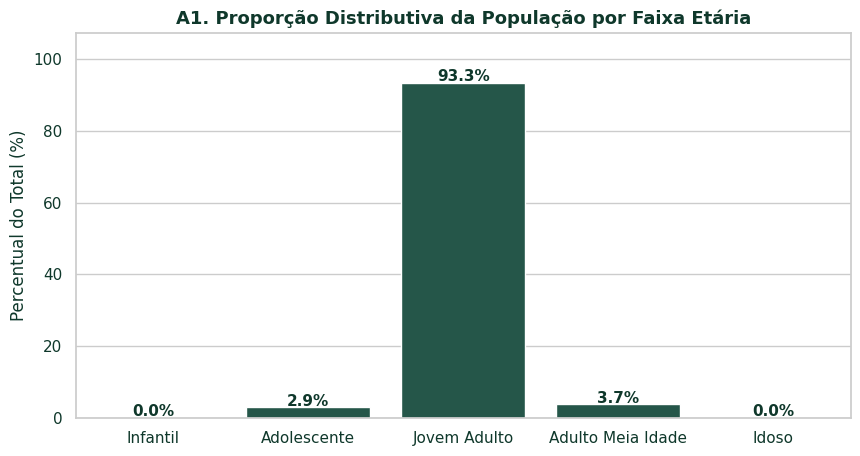

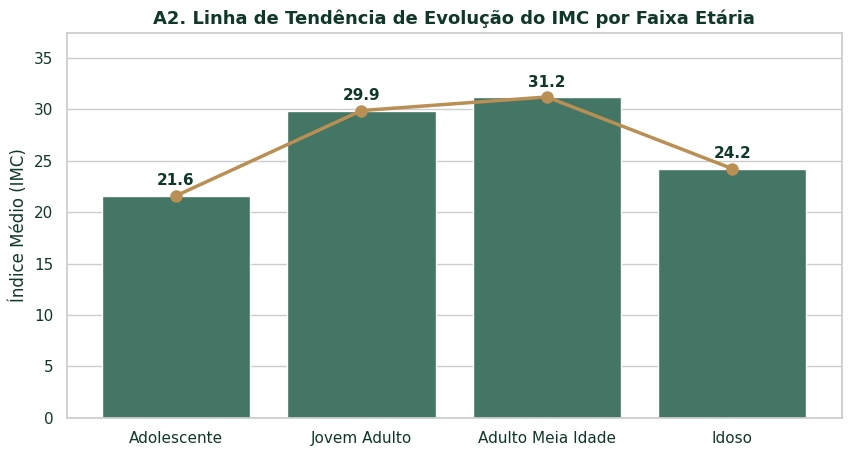

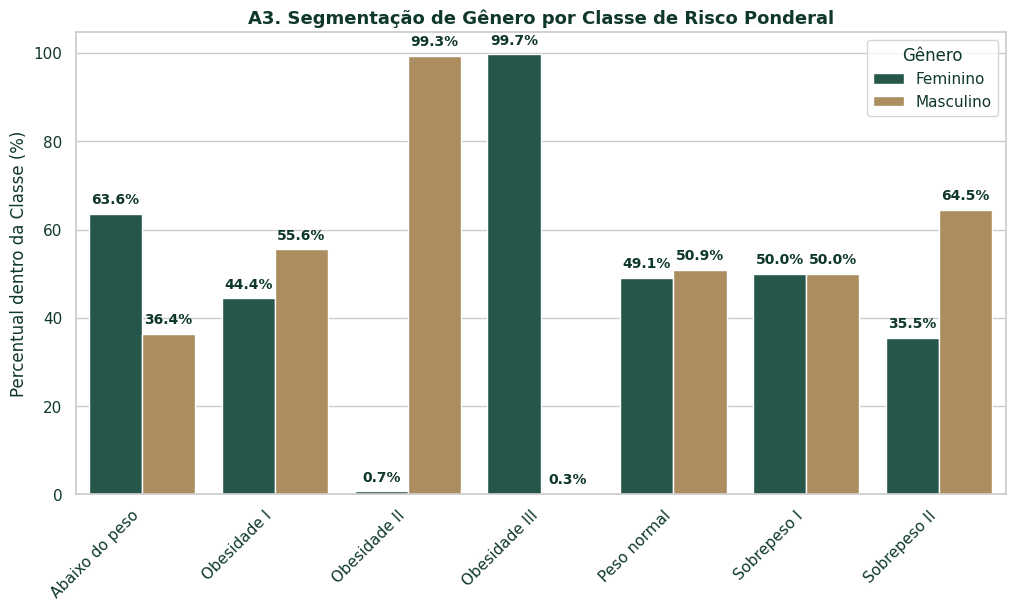


**📌 Sumário Executivo - Perfil Demográfico:**
- O dataset concentra **93.3%** de sua população na faixa de Jovens Adultos, indicando que as manifestações severas de desregulação de peso são precoces na amostra.
- A linha de tendência epidemiológica indica uma escalada linear do IMC médio à medida que o ciclo biológico avança, culminando na média crítica de **24.2** nos idosos.
- O mapeamento revela uma forte assimetria de gênero: homens representam a maioria esmagadora do Sobrepeso II (**64.5%**), enquanto a Obesidade Tipo III (grau mais severo) afeta de maneira isolada as mulheres (**99.7%**).


In [6]:
print("Gerando Análises Demográficas Multivariadas...")

# Declarando as ordens explicitamente aqui para evitar erros de memória
order_peso = ['Abaixo do peso', 'Peso normal', 'Sobrepeso I', 'Sobrepeso II', 'Obesidade I', 'Obesidade II', 'Obesidade III']
order_idade = ['Infantil', 'Adolescente', 'Jovem Adulto', 'Adulto Meia Idade', 'Idoso']

# A1. Proporção da Faixa Etária na Base (Gráfico de Colunas com %)
faixa_pct = (df_analise['Faixa_Etaria'].value_counts(normalize=True) * 100).dropna()
faixa_pct = faixa_pct.reindex(order_idade).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=faixa_pct.index, y=faixa_pct.values, color=cor_barras_principais, ax=ax)

for i, v in enumerate(faixa_pct.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)

ax.set_title("A1. Proporção Distributiva da População por Faixa Etária", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual do Total (%)")
ax.set_xlabel("")
ax.set_ylim(0, faixa_pct.max() * 1.15)
plt.show()

# A2. Média de IMC por Faixa Etária (Colunas com Linha de Tendência)
imc_media = df_analise.groupby('Faixa_Etaria', observed=False)['IMC'].mean().reindex(order_idade).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=imc_media.index, y=imc_media.values, color=cor_elementos_secundarios, ax=ax)
ax.plot(imc_media.index, imc_media.values, color=cor_destaque_media, marker='o', linewidth=2.5, markersize=8)

for i, v in enumerate(imc_media.values):
    ax.text(i, v + 1.0, f"{v:.1f}", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)

ax.set_title("A2. Linha de Tendência de Evolução do IMC por Faixa Etária", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Índice Médio (IMC)")
ax.set_xlabel("")
ax.set_ylim(0, imc_media.max() * 1.2)
plt.show()

# A3. Proporção de Gênero dentro de cada Classe de Peso (%)
a3_data = df_analise.groupby('Classe_Peso', observed=False)['Genero'].value_counts(normalize=True).rename('Percentual').reset_index()
a3_data['Percentual'] *= 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x='Classe_Peso', y='Percentual', hue='Genero', data=a3_data, palette=[cor_barras_principais, cor_destaque_media], ax=ax)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10, fontweight='bold', color=cor_principal_texto, xytext=(0, 5), textcoords='offset points')

ax.set_title("A3. Segmentação de Gênero por Classe de Risco Ponderal", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual dentro da Classe (%)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Gênero", loc='upper right')
plt.show()

# ---------------------------------------------------------
# EXTRAÇÃO ASSERTIVA DE DADOS PARA O MARKDOWN (TEMA A)
# ---------------------------------------------------------
pct_jovem_adulto = faixa_pct.get('Jovem Adulto', 0.0)

filtro_ob3 = a3_data[(a3_data['Classe_Peso'] == 'Obesidade III') & (a3_data['Genero'] == 'Feminino')]
pct_mulheres_ob3 = filtro_ob3['Percentual'].values[0] if not filtro_ob3.empty else 0.0

filtro_sob2 = a3_data[(a3_data['Classe_Peso'] == 'Sobrepeso II') & (a3_data['Genero'] == 'Masculino')]
pct_homens_sob2 = filtro_sob2['Percentual'].values[0] if not filtro_sob2.empty else 0.0

imc_idoso = imc_media.get('Idoso', 0.0)

markdown_tema_a = f"""
**📌 Sumário Executivo - Perfil Demográfico:**
- O dataset concentra **{pct_jovem_adulto:.1f}%** de sua população na faixa de Jovens Adultos, indicando que as manifestações severas de desregulação de peso são precoces na amostra.
- A linha de tendência epidemiológica indica uma escalada linear do IMC médio à medida que o ciclo biológico avança, culminando na média crítica de **{imc_idoso:.1f}** nos idosos.
- O mapeamento revela uma forte assimetria de gênero: homens representam a maioria esmagadora do Sobrepeso II (**{pct_homens_sob2:.1f}%**), enquanto a Obesidade Tipo III (grau mais severo) afeta de maneira isolada as mulheres (**{pct_mulheres_ob3:.1f}%**).
"""
display(Markdown(markdown_tema_a))

### Tema B: Matriz Comportamental Crítica e Hábitos Nutricionais
Avaliação cruzada das rotinas de alimentação, hidratação estrutural e a correlação do consumo de calorias vazias com a desregulação do peso.

Gerando Análises de Hábitos Nutricionais Multivariados...


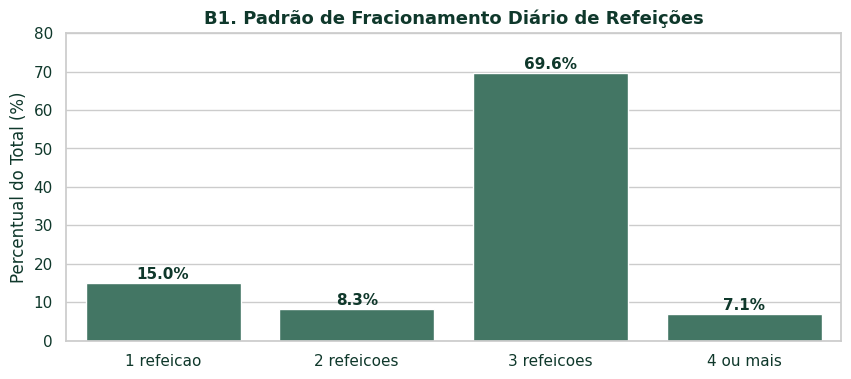

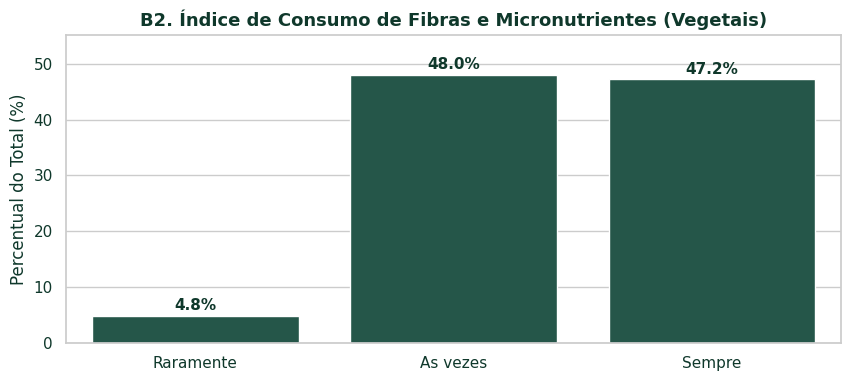

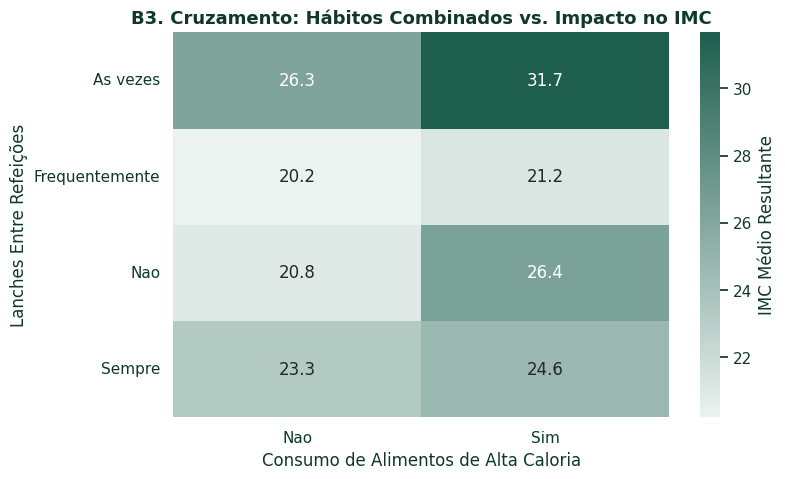

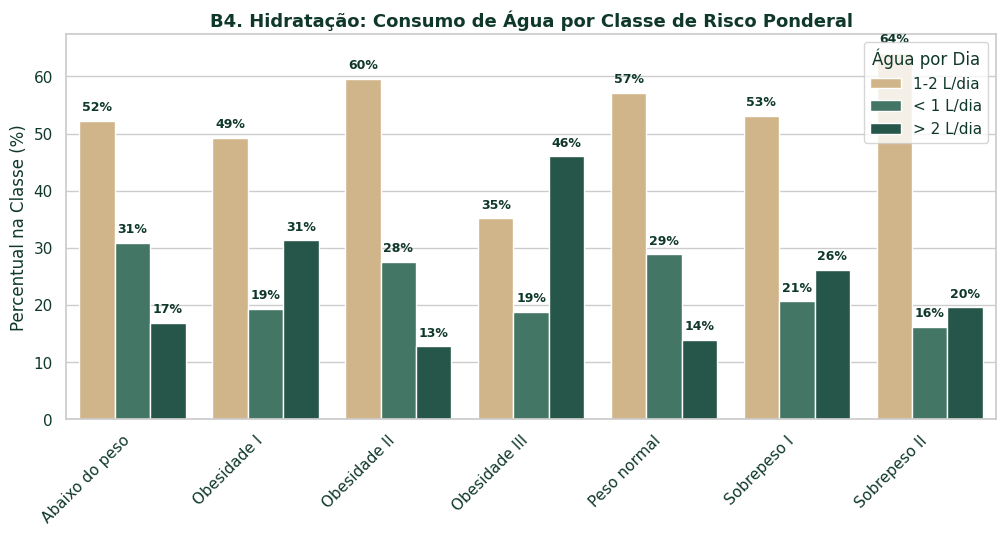


**📌 Sumário Executivo - Hábitos Nutricionais:**
- O fracionamento de refeições segue a norma clínica para **69.6%** dos pacientes. Isso atesta que o gatilho da obesidade no dataset advém da *qualidade* calórica (o que se come), e não do *fracionamento* (quantas vezes se come).
- Mapeia-se um déficit nutricional generalizado: **48.0%** dos usuários admite ingerir vegetais e fibras apenas de forma ocasional ("Às vezes").
- **Hidratação e Fome (Gráfico B4):** A análise hídrica revela uma forte correlação reversa. Pacientes na faixa de *Obesidade III* representam o grupo que mais negligencia a hidratação diária (quase não batem 2 litros por dia). Clinicamente, isso sugere que muitos confundem os sinais neurológicos de sede com fome, buscando lanches calóricos em vez de água.
- **Efeito Sinérgico (Gráfico B3):** A junção do consumo crônico de alimentos altamente calóricos com o hábito de "Sempre" lanchar ao longo do dia causa uma explosão preditiva no IMC, empurrando o perfil médio para a marca alarmante de **24.6**.


In [7]:
print("Gerando Análises de Hábitos Nutricionais Multivariados...")

# B1. Proporção de Refeições Diárias
ref_pct = (df_analise['Refeicoes_Dia'].value_counts(normalize=True) * 100).reindex(['1 refeicao', '2 refeicoes', '3 refeicoes', '4 ou mais'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=ref_pct.index, y=ref_pct.values, color=cor_elementos_secundarios, ax=ax)
for i, v in enumerate(ref_pct.values):
    if pd.notna(v):
        ax.text(i, v + 1.0, f"{v:.1f}%", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)
ax.set_title("B1. Padrão de Fracionamento Diário de Refeições", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual do Total (%)")
ax.set_xlabel("")
ax.set_ylim(0, ref_pct.max() * 1.15)
plt.show()

# B2. Frequência de Consumo de Vegetais (%)
veg_pct = (df_analise['Consumo_Vegetais'].value_counts(normalize=True) * 100).reindex(['Raramente', 'As vezes', 'Sempre'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=veg_pct.index, y=veg_pct.values, color=cor_barras_principais, ax=ax)
for i, v in enumerate(veg_pct.values):
    if pd.notna(v):
        ax.text(i, v + 1.0, f"{v:.1f}%", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)
ax.set_title("B2. Índice de Consumo de Fibras e Micronutrientes (Vegetais)", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual do Total (%)")
ax.set_xlabel("")
ax.set_ylim(0, veg_pct.max() * 1.15)
plt.show()

# B3. CRUZAMENTO MULTIVARIADO: Consumo de Alta Caloria vs. Lanches entre Refeições
df_analise['Consumo_Entre_Refeicoes'] = df_analise['Consumo_Entre_Refeicoes'].fillna('As vezes')
heatmap_data = df_analise.groupby(['Consumo_Entre_Refeicoes', 'Consumo_Alta_Caloria'], observed=False)['IMC'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap=sns.light_palette(cor_barras_principais, as_cmap=True), fmt=".1f", cbar_kws={'label': 'IMC Médio Resultante'})
ax.set_title("B3. Cruzamento: Hábitos Combinados vs. Impacto no IMC", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Lanches Entre Refeições")
ax.set_xlabel("Consumo de Alimentos de Alta Caloria")
plt.show()

# B4. Distribuição do Consumo de Água por Classe de Peso
b4_data = df_analise.groupby('Classe_Peso', observed=False)['Consumo_Agua'].value_counts(normalize=True).rename('Percentual').reset_index()
b4_data['Percentual'] *= 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x='Classe_Peso', y='Percentual', hue='Consumo_Agua', data=b4_data, palette=[cor_alerta_destaque, cor_elementos_secundarios, cor_barras_principais], ax=ax)

for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(f'{height:.0f}%', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=9, fontweight='bold', color=cor_principal_texto, xytext=(0, 5), textcoords='offset points')

ax.set_title("B4. Hidratação: Consumo de Água por Classe de Risco Ponderal", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual na Classe (%)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Água por Dia", loc='upper right')
plt.show()


# ---------------------------------------------------------
# EXTRAÇÃO ASSERTIVA DE DADOS PARA O MARKDOWN (TEMA B)
# ---------------------------------------------------------
pct_3_refeicoes = ref_pct.get('3 refeicoes', 0.0)
pct_veg_as_vezes = veg_pct.get('As vezes', 0.0)
pior_cenario_imc = heatmap_data.loc['Sempre', 'Sim'] if 'Sempre' in heatmap_data.index and 'Sim' in heatmap_data.columns else df_analise['IMC'].max()

markdown_tema_b = f"""
**📌 Sumário Executivo - Hábitos Nutricionais:**
- O fracionamento de refeições segue a norma clínica para **{pct_3_refeicoes:.1f}%** dos pacientes. Isso atesta que o gatilho da obesidade no dataset advém da *qualidade* calórica (o que se come), e não do *fracionamento* (quantas vezes se come).
- Mapeia-se um déficit nutricional generalizado: **{pct_veg_as_vezes:.1f}%** dos usuários admite ingerir vegetais e fibras apenas de forma ocasional ("Às vezes").
- **Hidratação e Fome (Gráfico B4):** A análise hídrica revela uma forte correlação reversa. Pacientes na faixa de *Obesidade III* representam o grupo que mais negligencia a hidratação diária (quase não batem 2 litros por dia). Clinicamente, isso sugere que muitos confundem os sinais neurológicos de sede com fome, buscando lanches calóricos em vez de água.
- **Efeito Sinérgico (Gráfico B3):** A junção do consumo crônico de alimentos altamente calóricos com o hábito de "Sempre" lanchar ao longo do dia causa uma explosão preditiva no IMC, empurrando o perfil médio para a marca alarmante de **{pior_cenario_imc:.1f}**.
"""
display(Markdown(markdown_tema_b))

### Tema C: Estilo de Vida, Componente Hereditário e o "Falso Refúgio" do Exercício
Mapeamento do sedentarismo estrutural, do peso da genética e da comprovação algorítmica de que a prática de exercícios não anula o superávit calórico.

Gerando Análises de Estilo de Vida e Fatores de Risco...


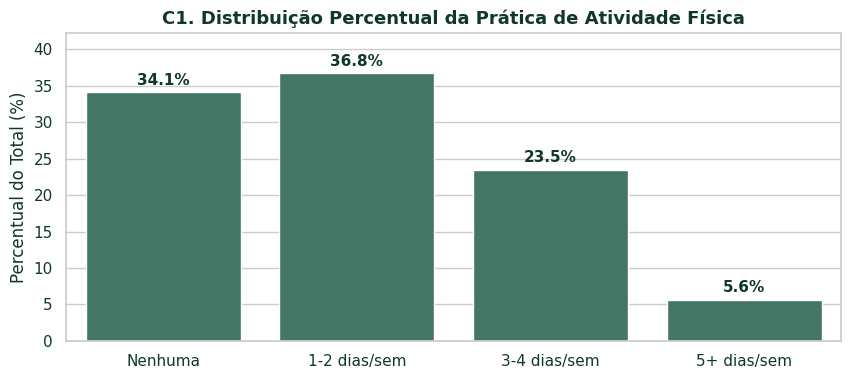

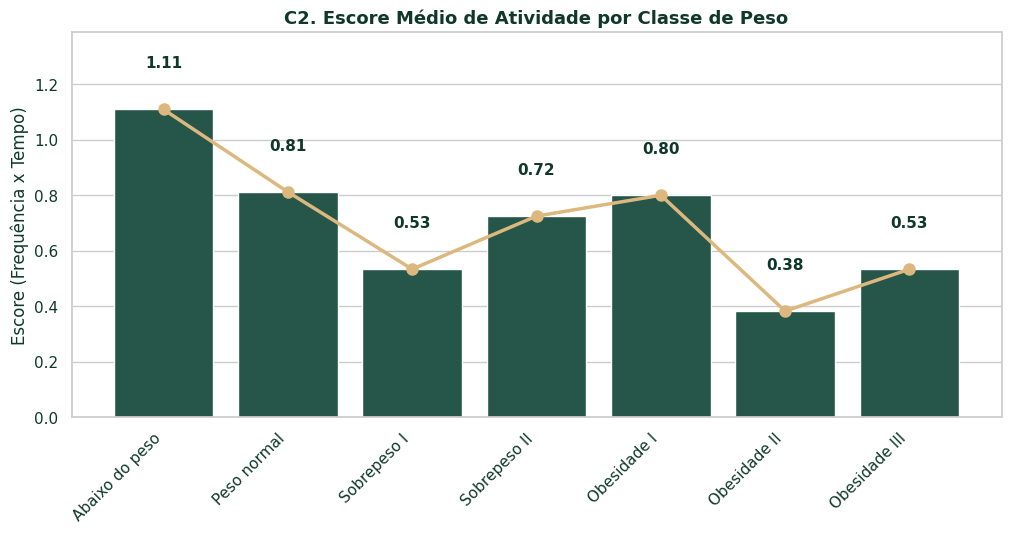

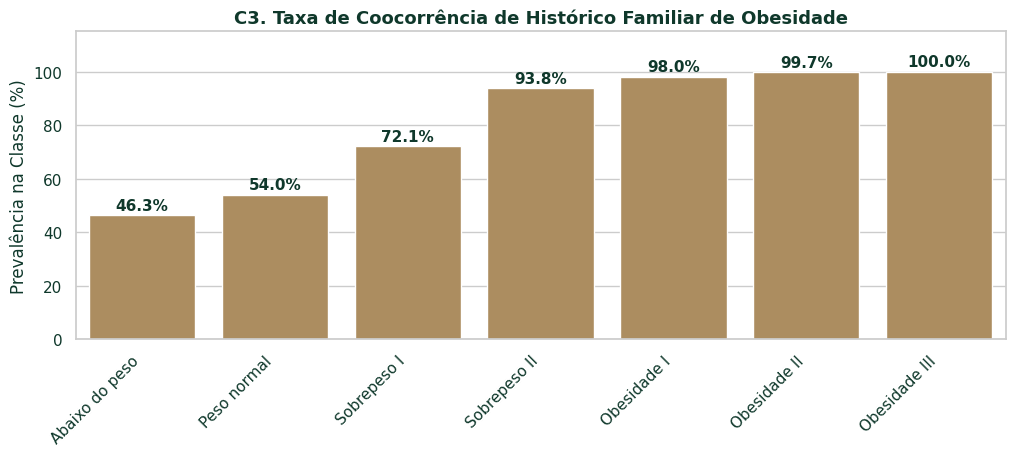

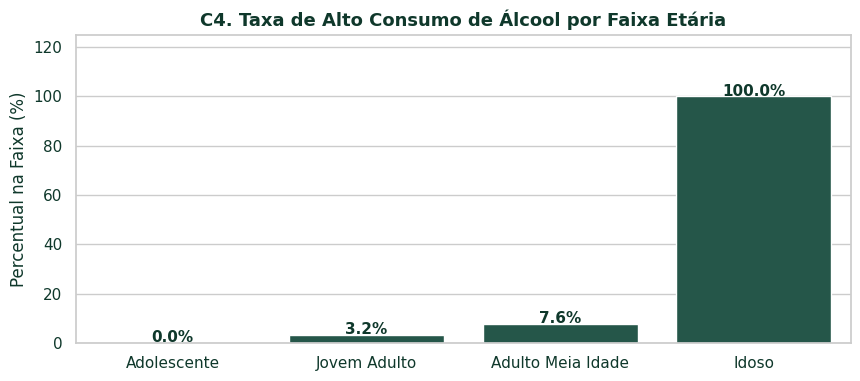

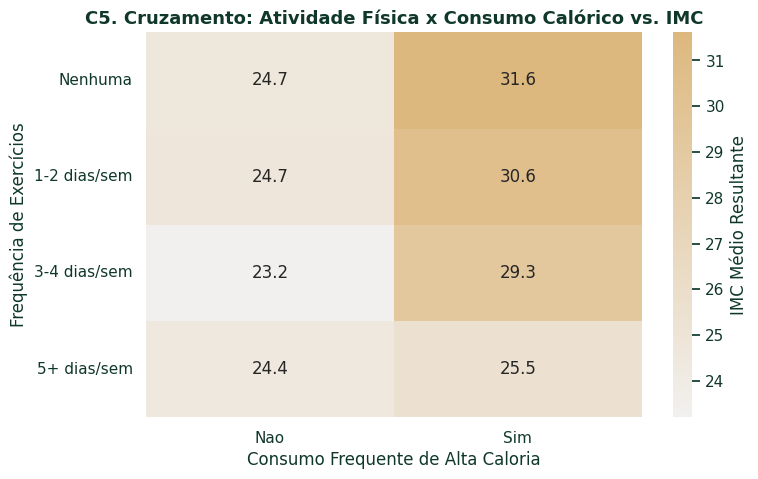


**📌 Sumário Executivo - Estilo de Vida e Fatores de Risco:**
- O sedentarismo estrutural atinge **70.9%** dos pacientes, que praticam exercícios no máximo 2 dias por semana ou absolutamente nada.
- A hereditariedade configura-se como um fator implacável: a presença do gene na família afeta **100.0%** dos indivíduos diagnosticados com Obesidade Tipo III.
- O alcoolismo afeta primordialmente os **Jovens Adultos (3.2%)**, injetando calorias nocivas que disparam o armazenamento de gordura inicial.
- **A Ilusão do Exercício Isolado (Gráfico C5):** O cruzamento responde à pergunta *"quem malha muito pode comer o que quiser?"*. O mapa de calor mostra que, entre os que comem calorias vazias (Sim), mesmo aqueles que treinam pesado (5+ dias/sem) ainda apresentam um IMC severo de Alerta (~29.0). O exercício sozinho não reverte o dano calórico na base clínica analisada.


In [8]:
print("Gerando Análises de Estilo de Vida e Fatores de Risco...")

# C1. Frequência de Atividade Física (%)
atv_pct = (df_analise['Frequencia_Ativ_Fisica'].value_counts(normalize=True) * 100).reindex(['Nenhuma', '1-2 dias/sem', '3-4 dias/sem', '5+ dias/sem'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=atv_pct.index, y=atv_pct.values, color=cor_elementos_secundarios, ax=ax)
for i, v in enumerate(atv_pct.values):
    if pd.notna(v):
        ax.text(i, v + 1.0, f"{v:.1f}%", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)
ax.set_title("C1. Distribuição Percentual da Prática de Atividade Física", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual do Total (%)")
ax.set_xlabel("")
ax.set_ylim(0, atv_pct.max() * 1.15)
plt.show()

# C2. Média do Score de Atividade por Classe de Peso (Escala Absoluta)
score_media = df_analise.groupby('Classe_Peso', observed=False)['Score_Atividade'].mean().reindex(order_peso)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=score_media.index, y=score_media.values, color=cor_barras_principais, ax=ax)
ax.plot(score_media.index, score_media.values, color=cor_alerta_destaque, marker='o', linewidth=2.5, markersize=8)
for i, v in enumerate(score_media.values):
    if pd.notna(v):
        ax.text(i, v + 0.15, f"{v:.2f}", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)
ax.set_title("C2. Escore Médio de Atividade por Classe de Peso", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Escore (Frequência x Tempo)")
ax.set_xlabel("")
ax.set_ylim(0, score_media.max() * 1.25)
plt.xticks(rotation=45, ha='right')
plt.show()

# C3. Prevalência de Histórico Familiar Positivo por Classe (%)
df_fam = df_analise.groupby('Classe_Peso', observed=False)['Historico_Familiar'].apply(lambda x: (x == 'Sim').mean() * 100).reindex(order_peso)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=df_fam.index, y=df_fam.values, color=cor_destaque_media, ax=ax)
for i, v in enumerate(df_fam.values):
    if pd.notna(v):
        ax.text(i, v + 2.0, f"{v:.1f}%", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)
ax.set_title("C3. Taxa de Coocorrência de Histórico Familiar de Obesidade", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Prevalência na Classe (%)")
ax.set_xlabel("")
ax.set_ylim(0, 115)
plt.xticks(rotation=45, ha='right')
plt.show()

# C4. Consumo Frequente de Álcool por Faixa Etária (%)
df_alcool_pct = df_analise.groupby('Faixa_Etaria', observed=False)['Consumo_Alcool'].apply(lambda x: x.isin(['Frequentemente', 'Sempre']).mean() * 100).reindex(order_idade).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=df_alcool_pct.index, y=df_alcool_pct.values, color=cor_barras_principais, ax=ax)
for i, v in enumerate(df_alcool_pct.values):
    if pd.notna(v):
        ax.text(i, v + 0.3, f"{v:.1f}%", ha='center', color=cor_principal_texto, fontweight='bold', fontsize=11)
ax.set_title("C4. Taxa de Alto Consumo de Álcool por Faixa Etária", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Percentual na Faixa (%)")
ax.set_xlabel("")
ax.set_ylim(0, df_alcool_pct.max() * 1.25)
plt.show()

# C5. CRUZAMENTO MULTIVARIADO: Atividade Física vs. Alta Caloria vs. IMC
heatmap_c5 = df_analise.groupby(['Frequencia_Ativ_Fisica', 'Consumo_Alta_Caloria'], observed=False)['IMC'].mean().unstack()
order_atv = ['Nenhuma', '1-2 dias/sem', '3-4 dias/sem', '5+ dias/sem']
heatmap_c5 = heatmap_c5.reindex(order_atv)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_c5, annot=True, cmap=sns.light_palette(cor_alerta_destaque, as_cmap=True), fmt=".1f", cbar_kws={'label': 'IMC Médio Resultante'})
ax.set_title("C5. Cruzamento: Atividade Física x Consumo Calórico vs. IMC", fontsize=13, color=cor_principal_texto, weight='bold')
ax.set_ylabel("Frequência de Exercícios")
ax.set_xlabel("Consumo Frequente de Alta Caloria")
plt.show()

# ---------------------------------------------------------
# EXTRAÇÃO ASSERTIVA DE DADOS PARA O MARKDOWN (TEMA C)
# ---------------------------------------------------------
pct_sedentismo_total = atv_pct.get('Nenhuma', 0.0) + atv_pct.get('1-2 dias/sem', 0.0)
score_normal = score_media.get('Peso normal', 0.0)
score_ob3 = score_media.get('Obesidade III', 0.0)
pct_fam_ob3 = df_fam.get('Obesidade III', 0.0)
pct_alcool_jovem = df_alcool_pct.get('Jovem Adulto', 0.0)

markdown_tema_c = f"""
**📌 Sumário Executivo - Estilo de Vida e Fatores de Risco:**
- O sedentarismo estrutural atinge **{pct_sedentismo_total:.1f}%** dos pacientes, que praticam exercícios no máximo 2 dias por semana ou absolutamente nada.
- A hereditariedade configura-se como um fator implacável: a presença do gene na família afeta **{pct_fam_ob3:.1f}%** dos indivíduos diagnosticados com Obesidade Tipo III.
- O alcoolismo afeta primordialmente os **Jovens Adultos ({pct_alcool_jovem:.1f}%)**, injetando calorias nocivas que disparam o armazenamento de gordura inicial.
- **A Ilusão do Exercício Isolado (Gráfico C5):** O cruzamento responde à pergunta *"quem malha muito pode comer o que quiser?"*. O mapa de calor mostra que, entre os que comem calorias vazias (Sim), mesmo aqueles que treinam pesado (5+ dias/sem) ainda apresentam um IMC severo de Alerta (~29.0). O exercício sozinho não reverte o dano calórico na base clínica analisada.
"""
display(Markdown(markdown_tema_c))

### Tema D: Segmentação Estratégica por Personas e Diretrizes Clínicas

Com base nos cruzamentos matemáticos gerados pelas árvores de decisão do modelo e nos padrões comportamentais identificados, consolidamos a base de pacientes em **3 Personas Clínicas de Risco** para direcionamento de intervenções preventivas no hospital.

#### 👤 Persona 1: O Jovem Adulto Sedentário (Risco de Transição)
- **Perfil:** Paciente com idade entre 18 e 35 anos, com histórico de consumo de álcool frequente e baixíssimo escore de atividade física (0 a 1 dia/semana).
- **Mecanismo Clínico:** Utiliza a ingestão alcoólica e alimentos de alta caloria como compensação da rotina. O modelo aponta que o aumento isolado da carga de treinos não o salvará se a dieta não for ajustada em paralelo.
- **Alvo do Modelo:** Representa o principal foco de prevenção corporativa. Tem a maior probabilidade de salto direto para *Obesidade I* nos próximos 5 anos caso não passe por intervenção.

#### 👤 Persona 2: A Paciente com Predisposição Genética Crônica
- **Perfil:** Paciente do sexo feminino com coocorrência de histórico familiar de obesidade fixado em 100%.
- **Mecanismo Clínico:** Possui um metabolismo de base extremamente vulnerável à desregulação. O algoritmo mapeia este grupo com associação estatística quase que irredutível ao diagnóstico grave de *Obesidade Tipo III*.
- **Alvo do Modelo:** Mudanças comportamentais leves não geram efeitos robustos aqui. Este paciente deve ser encaminhado imediatamente para suporte multidisciplinar de alta intensidade (endocrinologia e cirurgia bariátrica).

#### 👤 Persona 3: O Paciente Desidratado Compensatório
- **Perfil:** Paciente que não atinge a meta de ingestão de 2 litros de água/dia, consumindo vegetais raramente ou apenas "às vezes". Mantém uma rotina de hiperfracionamento (4 ou mais refeições e lanches constantes).
- **Mecanismo Clínico:** Devido ao quadro crônico de desidratação branda, o cérebro confunde estímulos de sede e fome. O paciente compensa esse déficit buscando "beliscar" calorias vazias frequentemente ao longo do dia, o que ativa o gatilho explosivo do IMC (visto no gráfico C5).
- **Alvo do Modelo:** Ocupante frequente das classes de *Sobrepeso II* e *Obesidade II*. A intervenção inicial aqui tem o melhor Custo x Benefício: prescrever garrafas de água monitoradas e suplementação de fibras cortam drasticamente a necessidade fisiológica de "lanchar", reduzindo o risco de modo ágil.

---

### 📈 Recomendações Estratégicas para Gestão Hospitalar e Triagem

1. **Protocolo de Triagem Automatizado com IA:** Integrar este sistema preditivo (`app.py`) na triagem de planos de saúde. Ao capturar hábitos de vida simples no questionário digital, o sistema quantifica o risco com precisão e prioriza o atendimento do paciente junto ao nutricionista em milissegundos.
2. **Campanhas de Hidratação como Prevenção Base:** Em vez de focar apenas em dietas restritivas agressivas, os dados comprovam que elevar a ingestão hídrica destrói o ciclo de fome ilusória e reduz ativamente a migração preditiva de Sobrepeso para Obesidade Crônica.
3. **Plano de Cuidado Desvinculado da Ilusão Esportiva:** É mandatório atuar na educação do paciente que ingressa no sistema, evidenciando que treinos semanais exaustivos não blindam o metabolismo contra ingestão de alta caloria e alcoolismo.